# Exercise 12-1: Another analysis of the Polling data

## Get the data

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import ticker

# Goals
Broad goal: Which sources appear most methodologically consistent and statistically dependable withing the data?

1. What pollsters were in the top 75th percentile for sample size? The assumption is more people sampled = better
2. Rank sources by average grade (comparability of grades must be implemented)
3. Separate sources into:
    3.1. High grade, low volume
    3.2. High grade, high volume
    3.3. Low grade, high volume
4. correlation between grade and weight
5. Comparison of pollsters by data quality (missing fields, unusual formatting, etc).

6. Identify each stage of the data analysis process and include a minimum of a paragraph of text/comments explaining the process for each of the steps. The more information you can include the better!


## Target Audience
The target audience is the political science community. As a data scientist, you need to know that you can count on the data you have to be accurate. Any politician or political scientist is going to ask the same question. Any insight derived on data you can't trust is worthless

*Read the data*

In [19]:
polls = pd.read_csv('data/president_general_polls_2016.csv')

*Inspect the data, So we know what we are working with*

In [20]:
polls.nunique()
polls.grade.unique()

<StringArray>
['A+', 'B', 'A-', 'B-', 'A', nan, 'B+', 'C+', 'C-', 'C', 'D']
Length: 11, dtype: str

In [21]:
polls.head()

,cycle,branch,type,matchup,forecastdate,state,startdate,enddate,pollster,grade,...,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin,multiversions,url,poll_id,question_id,createddate,timestamp
0,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,...,45.20163,41.72430,4.626221,NaN,NaN,https://www.washingtonpost.com/news/the-fix/wp...,48630,76192,11/7/16,09:35:33 8 Nov 2016
1,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,...,43.34557,41.21439,5.175792,NaN,NaN,https://datastudio.google.com/u/0/#/org//repor...,48847,76443,11/7/16,09:35:33 8 Nov 2016
2,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/2/2016,11/6/2016,Ipsos,A-,...,42.02638,38.81620,6.844734,NaN,NaN,http://projects.fivethirtyeight.com/polls/2016...,48922,76636,11/8/16,09:35:33 8 Nov 2016
3,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/4/2016,11/7/2016,YouGov,B,...,45.65676,40.92004,6.069454,NaN,NaN,https://d25d2506sfb94s.cloudfront.net/cumulus_...,48687,76262,11/7/16,09:35:33 8 Nov 2016
4,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,Gravis Marketing,B-,...,46.84089,42.33184,3.726098,NaN,NaN,http://www.gravispolls.com/2016/11/final-natio...,48848,76444,11/7/16,09:35:33 8 Nov 2016


In [22]:
polls.state.unique()

<StringArray>
[                'U.S.',           'New Mexico',             'Virginia',
                 'Iowa',            'Wisconsin',       'North Carolina',
              'Georgia',              'Florida',               'Oregon',
                 'Ohio',       'South Carolina',             'New York',
             'Michigan',         'Pennsylvania',             'Missouri',
        'New Hampshire',              'Arizona',               'Nevada',
             'Colorado',           'California',           'Washington',
                'Texas',                 'Utah',             'Illinois',
              'Indiana',            'Tennessee',          'Connecticut',
        'Massachusetts',           'New Jersey',               'Kansas',
             'Kentucky',            'Minnesota',             'Oklahoma',
             'Maryland',              'Alabama',             'Nebraska',
            'Louisiana',                'Maine',             'Arkansas',
               'Alaska',             

In [23]:
# call the info() method
polls.info()

<class 'pandas.DataFrame'>
RangeIndex: 12624 entries, 0 to 12623
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cycle             12624 non-null  int64  
 1   branch            12624 non-null  str    
 2   type              12624 non-null  str    
 3   matchup           12624 non-null  str    
 4   forecastdate      12624 non-null  str    
 5   state             12624 non-null  str    
 6   startdate         12624 non-null  str    
 7   enddate           12624 non-null  str    
 8   pollster          12624 non-null  str    
 9   grade             11337 non-null  str    
 10  samplesize        12621 non-null  float64
 11  population        12624 non-null  str    
 12  poll_wt           12624 non-null  float64
 13  rawpoll_clinton   12624 non-null  float64
 14  rawpoll_trump     12624 non-null  float64
 15  rawpoll_johnson   8397 non-null   float64
 16  rawpoll_mcmullin  90 non-null     float64
 17  adjp

In [24]:
poll_weight = polls['poll_wt'].value_counts()
poll_weight

poll_wt
0.000000    480
1.770959     15
0.296849     15
0.227946     15
0.226658     15
           ... 
0.000004      1
0.000004      1
0.000001      1
0.137472      1
0.010132      1
Name: count, Length: 4399, dtype: int64

## Clean the data

Because we are actually trying to understand which pollsters are reliable, we are intentionally not droping any missing data just yet.

Drop the columns that are not relevant to our analysis
1. Timestamp has only 3 unique values they're all within 20 minutes of each other on the same day. This field seems to be an insertion timestamp, like into a DB, and is of no value here.
2. the start date and the end date a presumably when the polling started and ended. This has importance in the sense that, if the polling goes on for a while, events are likely to occur that would otherwise change perceptions. However, while that is important, it isn't important for our objectives
3. The created date has no meta data to leverage, and doesn't give me any reason to keep it
4. In addition, the date formatting for each is inconsistent

In [25]:
polls = polls.drop(columns=['startdate', 'enddate', 'timestamp', 'createddate'])


We also need to drop values with invalid poll weights, but only after they have been counted

## Prepare the data
### Remapping the grades to something we can work with

The grades are not usable as letters, since they don't have a natural sort order. We need to map them to numeric values to perform calculations. However, we want to keep the original letter grades for show-and-tell purposes. We'll use a dictionary to map the letter grades to numeric values instead of getting clever with math

In [26]:
polls['national'] = polls.state == 'U.S.'

grade_map = {
    'A+': 4.3,
    'A': 4.0,
    'A-': 3.7,
    'B+': 3.3,
    'B': 3.0,
    'B-': 2.7,
    'C+': 2.3,
    'C': 2.0,
    'C-': 1.7,
    'D+': 1.3,
    'D': 1.0,
    'D-': 0.7,
    'F': 0.0
}

# 2. Calculate the average to handle NaNs
# We map it once just to get the mean value
avg_val = polls.grade.map(grade_map).mean()
polls['grade_numeric'] = polls.grade.map(grade_map).fillna(avg_val)


## Analyze the data

The sample size is currently of type float. However, this has some implications and not in a good way:
1. You can't have a partial sample size (like 1.5), so the use of a float is not appropriate and gives no benefit. And, in fact, floating point number math is actually slower than integer math
2. Because Float has the `NaN` value, which is not a valid sample size, it can't be used in calculations. We can't realistically say the sample size is 0, because that would mean we didn't poll anyone, but we also can't perform calculations with `NaN` values. We also can't directly convert `NaN` to int, so we realistically need to drop all rows with a sample size as `NaN` as it's effectively not usable

## What pollsters were in the top 75th percentile for sample size?
The assumption is more people sampled = better. We get the data we need here but will show it in a graph later

In [27]:
# 1. Clean the data
temp_polls = polls.dropna(subset=['samplesize'])
temp_polls['samplesize'] = temp_polls['samplesize'].astype(int)

# 2. Group and convert to DataFrame in one step
pollster_sample_sizing = (
    polls.groupby('pollster')
    .agg(total_samples=('samplesize', 'sum'))
    .sort_values('total_samples', ascending=False)
)

pollster_sample_sizing

,total_samples
pollster,
SurveyMonkey,3814389.0
Ipsos,2031246.0
Google Consumer Surveys,1883712.0
USC Dornsife/LA Times,913488.0
YouGov,770634.0
...,...
Craciun Research,1200.0
R.L. Repass & Partners,1158.0
Dartmouth College,1086.0


## Rank Sources by Grade
Now that grades are numeric, we can rank pollsters by their average grade. We'll use a Bayesian score to adjust for sample size, ensuring that pollsters with small sample sizes are not unfairly ranked higher. This is a fairer comparison than simply ranking by average grade and is considered the gold standard for this kind of analysis.


In [28]:
# by using a bayesien score we make sure no one gets lucky
def calculate_bayesian_score(df, m=1000):
    """
    PURPOSE: Adjusts the raw average grade based on sample volume.
    FAIRNESS: Prevents high-rankings for pollsters with very low sample sizes
    (the "Small Sample Bias"). It anchors every pollster to the global mean
    until their own data volume is large enough to prove their performance.
    """
    # Calculate the global average grade across the entire dataset
    # We use a global constant so every pollster is compared to the same 'Truth'
    global_mean = polls['grade_numeric'].mean()

    # Formula: (Volume * Rate + Threshold * Global_Mean) / (Volume + Threshold)
    # As Volume (v) increases, the impact of the Global_Mean (C) diminishes.
    v = df['total_volume']
    r = df['avg_grade']

    return (v * r + m * global_mean) / (v + m)


pollster_stats = (
    polls.groupby('pollster')
    .agg(
        avg_grade=('grade_numeric', 'mean'),
        total_volume=('samplesize', 'sum')
    )
    .assign(
        bayesian_score=calculate_bayesian_score
    )
    .sort_values('bayesian_score', ascending=False)
)
pollster_stats

,avg_grade,total_volume,bayesian_score
pollster,,,
ABC News/Washington Post,4.3,88248.0,4.284927
Monmouth University,4.3,55872.0,4.276346
Selzer & Company,4.3,29325.0,4.255640
Field Research Corporation (Field Poll),4.3,8691.0,4.161188
Marist College,4.0,158619.0,3.993452
...,...,...,...
McLaughlin & Associates,1.7,7806.0,1.842491
Opinion Savvy/InsiderAdvantage,1.7,20253.0,1.759040
Zogby Interactive/JZ Analytics,1.7,30486.0,1.739852


## Comparison of pollsters by data quality (missing fields, unusual formatting, etc).

Here we are checking for a few things:
1. any rows with a sample size of NaN can't be used. However, we are going to use this to determine data quality by pollster
2. Emtpy strings are invalid only for string columns, DUH!
3. Poll weight must also be positive and non-zero because this is used to form a composite score.

In [29]:
# any rows with a sample size of NaN can't be used. However, we are going to use this to determine data quality by pollster

string_cols = polls.select_dtypes(include=["object", "string"]).columns

# blank strings are invalid only for string columns
blank_mask = polls[string_cols].apply(lambda x: x.fillna("").str.strip() == "")

invalid_poll_wt = polls[polls.poll_wt.isna() | polls.poll_wt <= 0]

# NaN is invalid for every column
invalid_mask = polls.isna().copy()

# 1. Create a Series mask (True for invalid weights, False otherwise)
# This keeps the original index length, avoiding the ValueError
invalid_poll_wt_mask = polls.poll_wt.isna() | (polls.poll_wt <= 0)

# 2. Use .iloc to broadcast the Series across the string columns correctly
# We use .values or ensure the index aligns so it applies to every column in the selection
invalid_mask[string_cols] = invalid_mask[string_cols] | blank_mask.values | invalid_poll_wt_mask.values[:, None]

# total invalid columns in each row
row_invalid_total = invalid_mask.sum(axis=1)

# aggregate by pollster
pollster_invalid_stats = (
    polls.assign(row_invalid_total=row_invalid_total)
    .groupby("pollster", dropna=False)["row_invalid_total"]
    .agg(
        rows="size",
        total_invalid="sum",
        mean_invalid="mean",
        median_invalid="median",
        std_invalid="std"
    )
    .assign(
        invalid_rate=lambda df: df["total_invalid"] / df["rows"]
    )
    .sort_values(["total_invalid", "mean_invalid"], ascending=False)
)

pollster_invalid_stats


,rows,total_invalid,mean_invalid,median_invalid,std_invalid,invalid_rate
pollster,,,,,,
Ipsos,2757,13986,5.072905,5.0,2.065715,5.072905
Google Consumer Surveys,2229,7071,3.172275,3.0,1.230202,3.172275
SurveyMonkey,1980,5955,3.007576,3.0,0.493969,3.007576
USC Dornsife/LA Times,363,2178,6.000000,6.0,0.000000,6.000000
CVOTER International,345,1725,5.000000,5.0,0.000000,5.000000
...,...,...,...,...,...,...
University of New Orleans,3,9,3.000000,3.0,0.000000,3.000000
Vanderbilt University,3,9,3.000000,3.0,0.000000,3.000000
Vox Populi Communications,3,9,3.000000,3.0,0.000000,3.000000


## Visualize the data

Separate sources into:
1. High grade, low volume
2. High grade, high volume
3. Low grade, high volume

Ok, so the trick here is to use the mean grade and mean volume as thresholds to categorize pollsters. We'll use these thresholds to group pollsters into one of the three categories and assign a color to each group for visualization purposes.

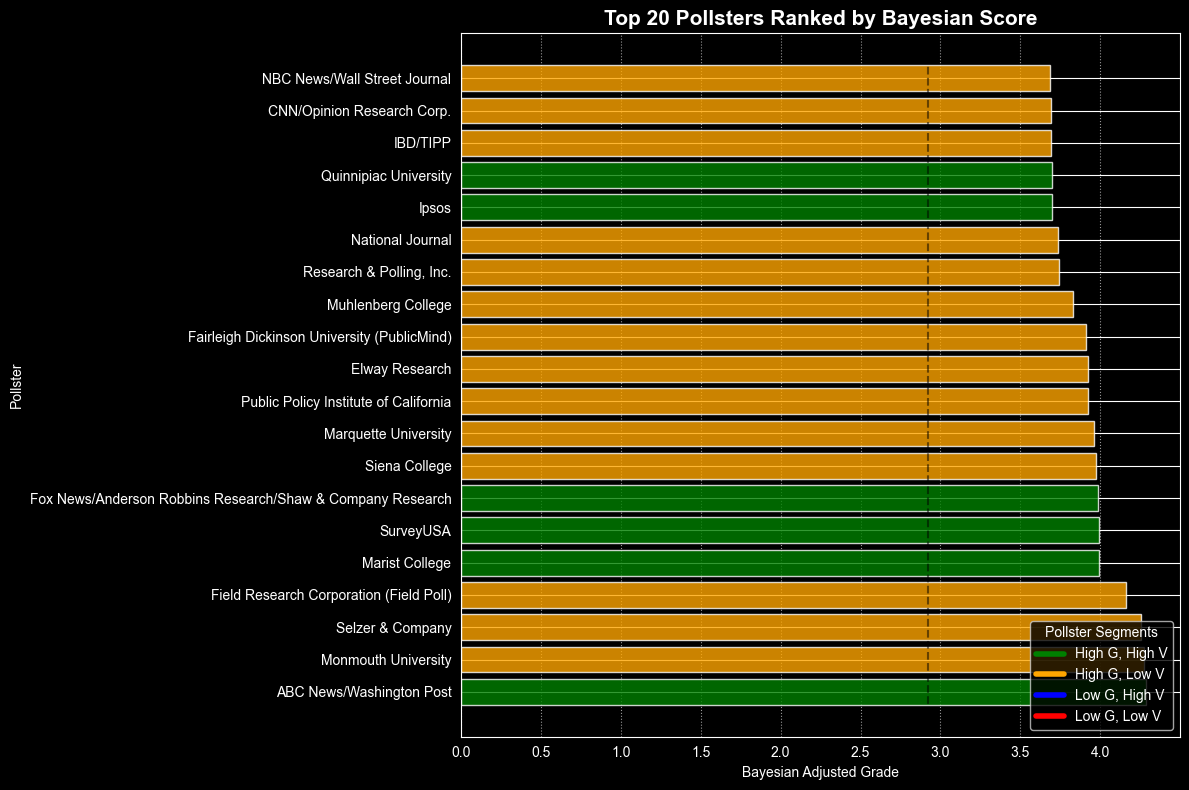

<Figure size 640x480 with 0 Axes>

In [30]:
# We'll use a plot with subplots to show the 3 different combos
# and ultimately show who's the most reliable pollster
mean_grade = pollster_stats['avg_grade'].mean()
mean_volume = pollster_stats['total_volume'].mean()

def assign_group(row):
    if row['avg_grade'] > mean_grade and row['total_volume'] > mean_volume:
        return 'High Grade, High Volume', 'green'
    if row['avg_grade'] > mean_grade:
        return 'High Grade, Low Volume', 'orange'
    if row['total_volume'] > mean_volume:
        return 'Low Grade, High Volume', 'blue'
    else:
        return 'Low Grade, Low Volume', 'red'

# Apply grouping
groups_and_colors = pollster_stats.apply(assign_group, axis=1)
pollster_stats['group'] = [x[0] for x in groups_and_colors]
pollster_stats['color'] = [x[1] for x in groups_and_colors]

# Top 20 only. Too many pollsters to show all
plot_df = pollster_stats.sort_values('bayesian_score', ascending=False).head(20)

plt.figure(figsize=(12, 8))

bars = plt.barh(plot_df.index, plot_df['bayesian_score'], color=plot_df['color'], alpha=0.8)

# 5. Add a legend manually since we colored bars individually

legend_elements = [
    Line2D([0], [0], color='green', lw=4, label='High G, High V'),
    Line2D([0], [0], color='orange', lw=4, label='High G, Low V'),
    Line2D([0], [0], color='blue', lw=4, label='Low G, High V'),
    Line2D([0], [0], color='red', lw=4, label='Low G, Low V')
]

plt.legend(handles=legend_elements, title="Pollster Segments", loc='lower right')

# 6. Formatting
plt.axvline(mean_grade, color='black', linestyle='--', alpha=0.5, label='Global Average')
plt.title('Top 20 Pollsters Ranked by Bayesian Score', fontsize=15, fontweight='bold')
plt.xlabel('Bayesian Adjusted Grade')
plt.ylabel('Pollster')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Junwen Jiang## Invalid polster data

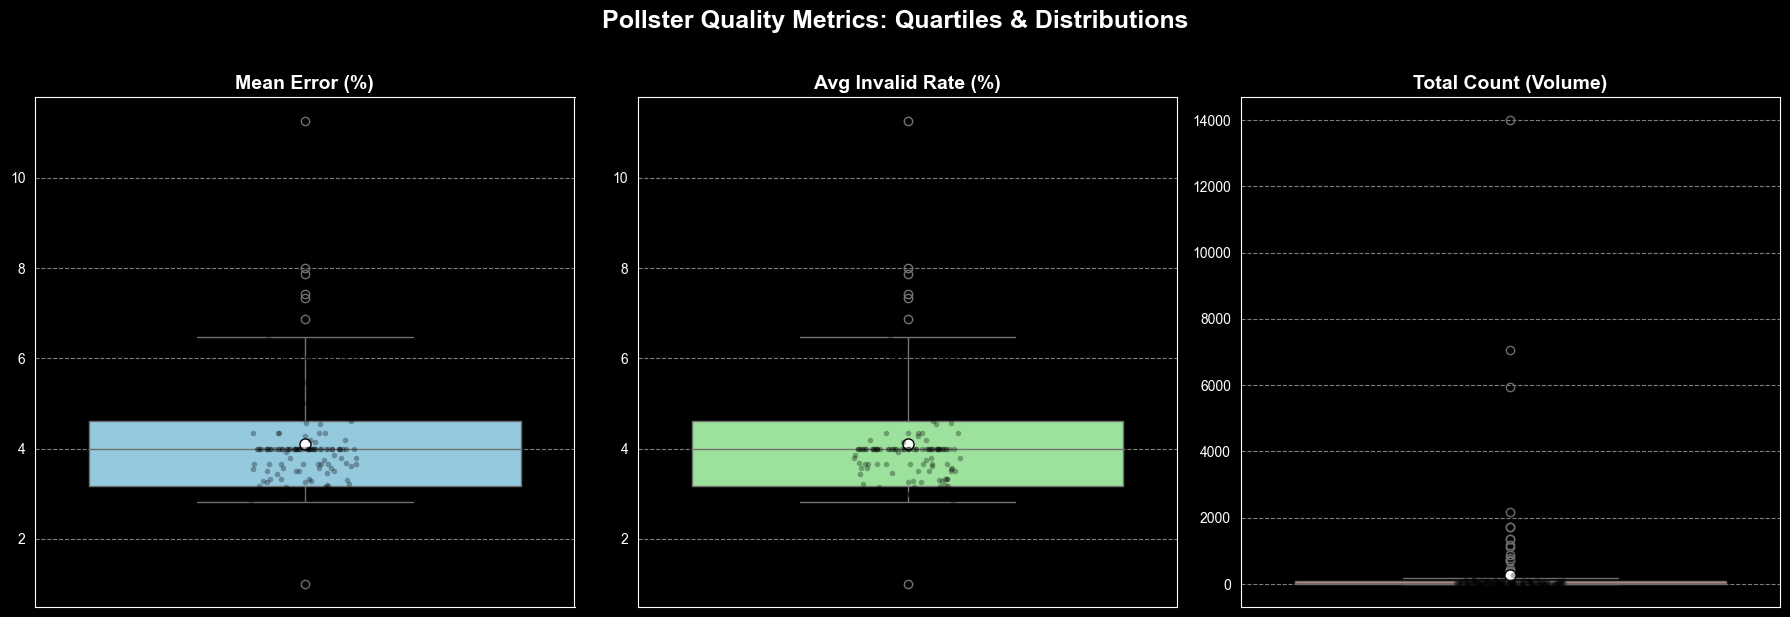

In [31]:
# Setup a 1x3 grid for the subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the metrics and their display settings
pollster_metrics = [
    ('mean_invalid', 'Mean Error (%)', 'skyblue'),
    ('invalid_rate', 'Avg Invalid Rate (%)', 'lightgreen'),
    ('total_invalid', 'Total Count (Volume)', 'salmon')
]

for i, (col, title, color) in enumerate(pollster_metrics):
    # Create the boxplot
    sns.boxplot(
        y=pollster_invalid_stats[col],
        ax=axes[i],
        color=color,
        showmeans=True,  # Displays the mean as a marker
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8"
        }
    )

    # Overlay individual pollsters as "jitter" points for extra detail
    sns.stripplot(
        y=pollster_invalid_stats[col],
        ax=axes[i],
        color='black',
        alpha=0.3,
        size=4,
        jitter=True
    )

    axes[i].set_title(title, fontweight='bold', fontsize=14)
    axes[i].set_ylabel('')  # Y-axis label removed to keep it clean
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Pollster Quality Metrics: Quartiles & Distributions', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()

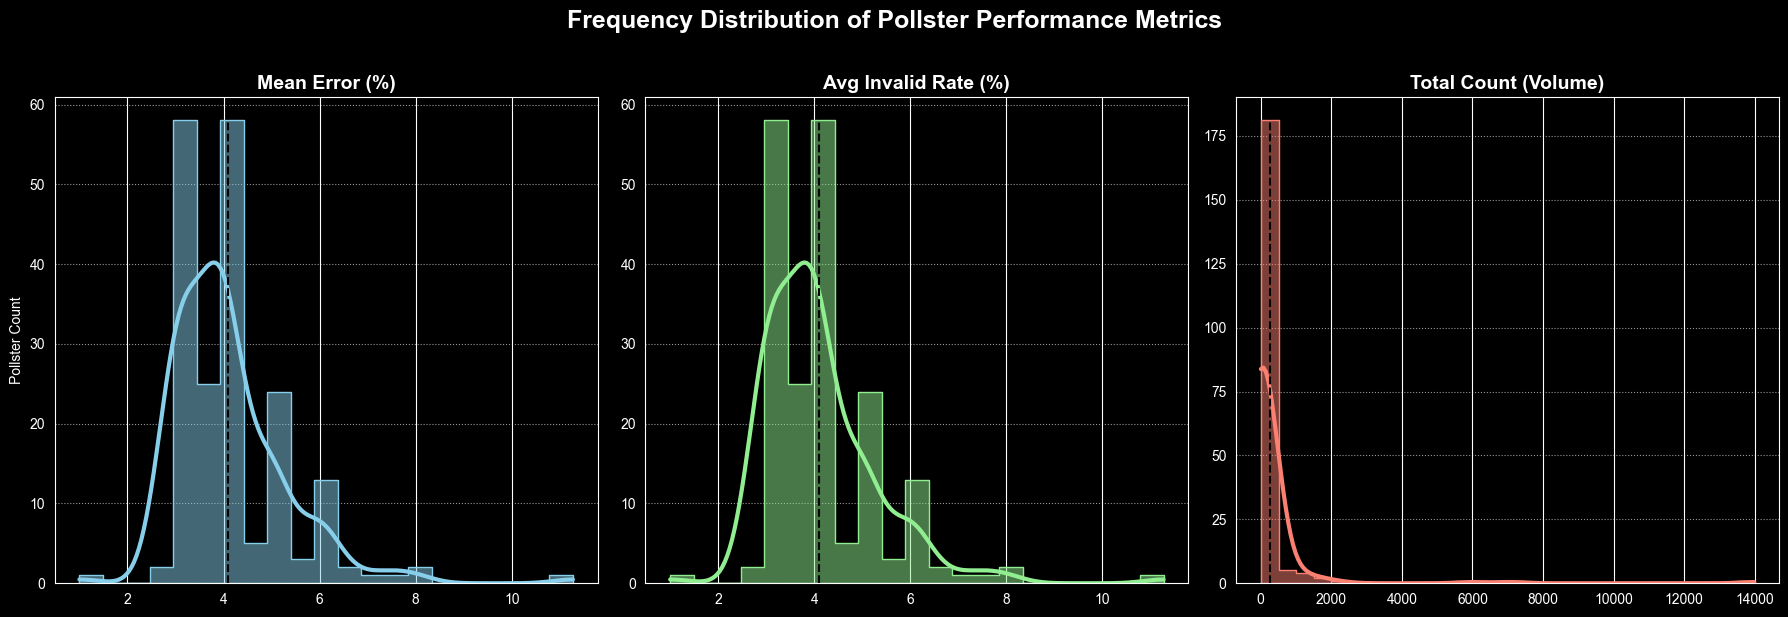

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, title, color) in enumerate(pollster_metrics):
    # Create the histogram with a density curve
    sns.histplot(
        pollster_invalid_stats[col],
        ax=axes[i],
        color=color,
        kde=True,          # Adds the smooth density curve
        line_kws={'lw': 3}, # Makes the KDE line thicker
        element="step"     # Makes the bars look cleaner
    )

    # Add a vertical line for the mean to help with interpretation
    axes[i].axvline(pollster_invalid_stats[col].mean(), color='black', linestyle='--', label='Mean')

    axes[i].set_title(title, fontweight='bold', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Pollster Count' if i == 0 else '') # Only label the first Y-axis
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle('Frequency Distribution of Pollster Performance Metrics', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

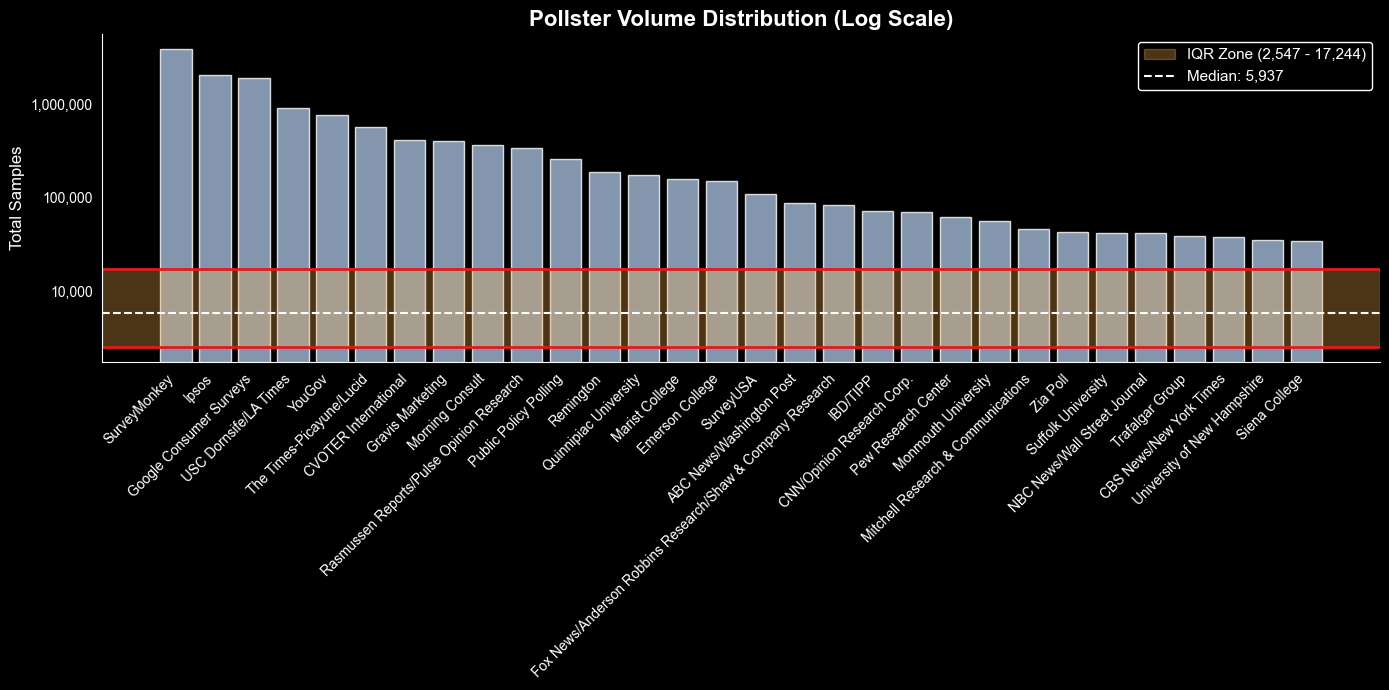

In [33]:
# 1. Calculate the benchmarks
q1 = pollster_sample_sizing['total_samples'].quantile(0.25)
q3 = pollster_sample_sizing['total_samples'].quantile(0.75)
median = pollster_sample_sizing['total_samples'].median()

# 2. Setup the plot
plt.figure(figsize=(14, 7))
top_30 = pollster_sample_sizing.head(30)

# Create bars
plt.bar(top_30.index, top_30['total_samples'], color='#a6bddb', alpha=0.8)

# 3. Apply LOG SCALE
plt.yscale('log')

# 4. Use FuncFormatter to turn off scientific notation and add commas
# This makes labels like 1,000, 10,000, 100,000 instead of 10^3, 10^4...
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_minor_formatter(ticker.NullFormatter()) # Clean up minor ticks

# 5. Pronounced IQR Indicators
plt.axhspan(q1, q3, color='#feb24c', alpha=0.3, label=f'IQR Zone ({int(q1):,} - {int(q3):,})')
plt.axhline(q3, color='#e31a1c', linestyle='-', linewidth=2)
plt.axhline(q1, color='#e31a1c', linestyle='-', linewidth=2)
plt.axhline(median, color='white', linestyle='--', linewidth=1.5, label=f'Median: {int(median):,}')

# 6. Clean Aesthetics (No grid, clean spines)
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Labels
plt.title('Pollster Volume Distribution (Log Scale)', fontsize=16, fontweight='bold')
plt.ylabel('Total Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(
    loc='upper right',
    frameon=True,          # Turn the box back on
    facecolor='black',     # Solid white background
    edgecolor='white',     # Sharp black border
    framealpha=1,          # 100% opacity (no ghosting through)
    shadow=True,           # Adds a slight shadow to make it "float"
    fontsize=11
)

plt.tight_layout()
plt.show()

## correlation between grade and weight

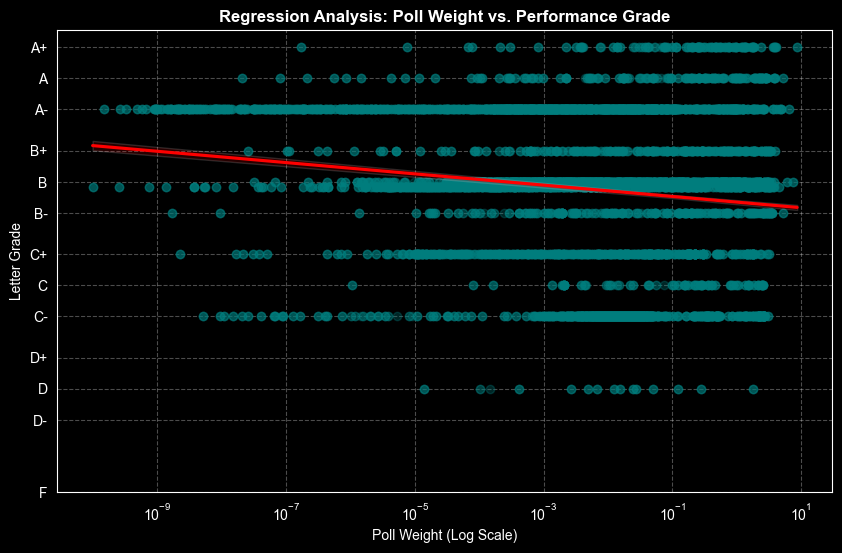

In [34]:

plt.figure(figsize=(10, 6))
# drop any without a poll weight
polls = polls[polls.poll_wt.notna() & polls.poll_wt > 0]
# logx=True plots the regression line based on the log of the x-axis
sns.regplot(
    data=polls,
    x='poll_wt',
    y='grade_numeric',
    logx=True,
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red'}
)

plt.yticks(list(grade_map.values()), list(grade_map.keys()))

# 4. Final Formatting
plt.xscale('log')  # Essential for visualizing weights/sample sizes
plt.title('Regression Analysis: Poll Weight vs. Performance Grade', fontweight='bold')
plt.xlabel('Poll Weight (Log Scale)')
plt.ylabel('Letter Grade')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()